In [1]:
import pandas as pd

train_df = pd.read_csv("Titanic_train.csv")
test_df = pd.read_csv("Titanic_test.csv")

train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
train_df.shape

(891, 12)

In [3]:
train_df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [4]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

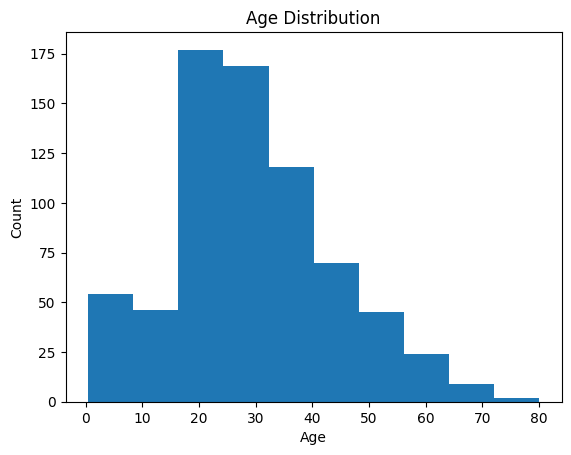

In [6]:
plt.hist(train_df['Age'].dropna())
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

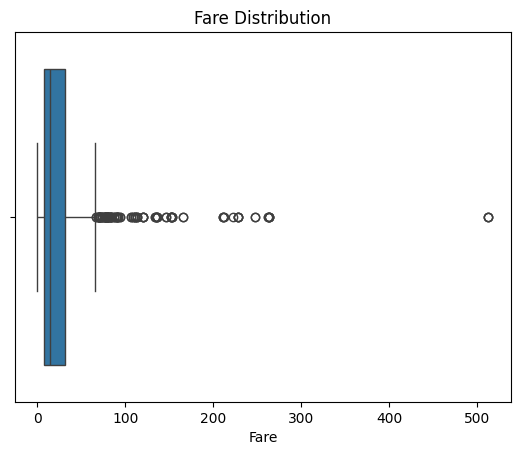

In [7]:
sns.boxplot(x=train_df['Fare'])
plt.title("Fare Distribution")
plt.show()

In [8]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

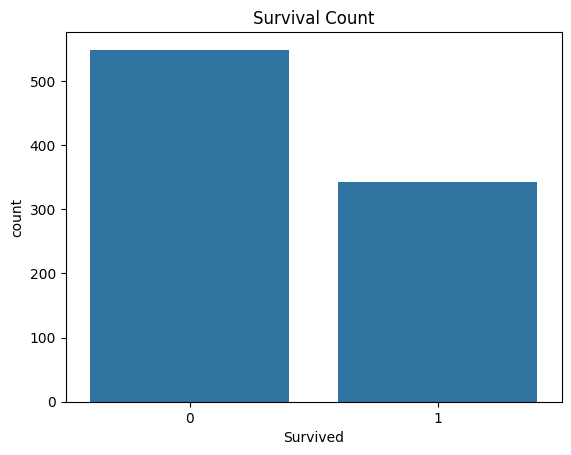

In [9]:
sns.countplot(x='Survived', data=train_df)
plt.title("Survival Count")
plt.show()

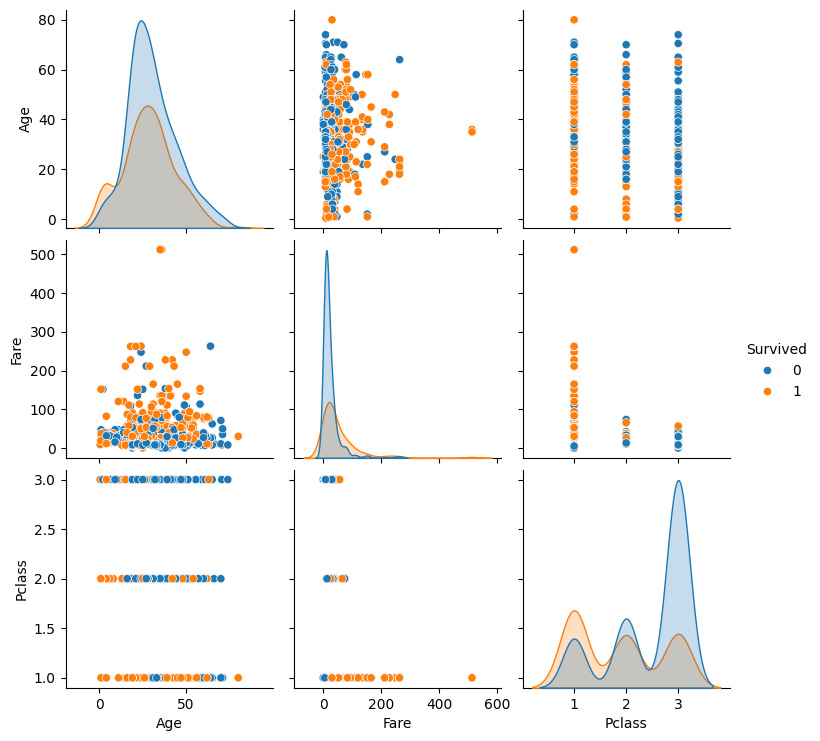

In [10]:
sns.pairplot(train_df[['Survived', 'Age', 'Fare', 'Pclass']].dropna(),
             hue='Survived')
plt.show()

In [11]:
# Fill missing Age with median
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

# Fill missing Embarked with mode
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])

# Fill missing Fare in test set
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())


In [12]:
# Convert categorical variables to numerical
train_df = pd.get_dummies(train_df, columns=['Sex', 'Embarked'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Sex', 'Embarked'], drop_first=True)


In [13]:
features = ['Pclass', 'Age', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
X_train = train_df[features]
y_train = train_df['Survived']

X_test = test_df[features]


In [14]:
from sklearn.model_selection import train_test_split

X = train_df[features]
y = train_df['Survived']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
from sklearn.linear_model import LogisticRegression
import joblib

model = LogisticRegression(
    solver="liblinear",
    max_iter=1000
)

model.fit(X_train, y_train)

joblib.dump(model, "titanicmodel.pkl")


['titanicmodel.pkl']

In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

# Train model again
model.fit(X_tr, y_tr)

# Predictions
y_pred = model.predict(X_te)
y_prob = model.predict_proba(X_te)[:, 1]

print("Accuracy:", accuracy_score(y_te, y_pred))
print("Precision:", precision_score(y_te, y_pred))
print("Recall:", recall_score(y_te, y_pred))
print("F1 Score:", f1_score(y_te, y_pred))
print("ROC-AUC:", roc_auc_score(y_te, y_prob))


Accuracy: 0.7877094972067039
Precision: 0.7571428571428571
Recall: 0.7162162162162162
F1 Score: 0.7361111111111112
ROC-AUC: 0.8754182754182753


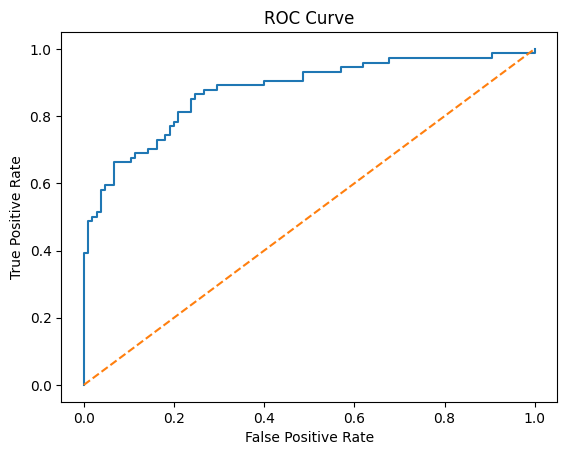

In [17]:
fpr, tpr, _ = roc_curve(y_te, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [18]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

coefficients


,Feature,Coefficient
0,Pclass,-0.782503
1,Age,-0.015493
2,Fare,0.002455
3,Sex_male,-2.338656
4,Embarked_Q,-0.021747
5,Embarked_S,-0.359289


#### What is the difference between precision and recall?

**Precision**

- Tells you how reliable the positive predictions are ,if the model says “yes,” how often it’s actually right.

- Focuses on avoiding false alarms — it punishes cases where the model incorrectly labels something as positive.

- Used when false positives are costly or problematic (e.g., incorrectly flagging important emails as spam).

- Think of it as the model’s trustworthiness when it predicts a positive.

**Recall**

- Tells you how complete the model is at capturing positives — how many of the actual positive cases it finds.

- Focuses on finding all real positives, even if it catches some wrong ones too.

- Used when missing a positive is costly (e.g., failing to detect a disease).

- Think of it as the model’s ability to not overlook any real positives.



#### What is cross-validation, and why is it important in binary classification?

Cross-validation is a way to check how well a machine learning model works on new (unseen) data by testing it on multiple different subsets of your dataset — not just one fixed train/test split. It involves:

- Splitting the dataset into several parts (folds).

- Training the model on some parts and testing it on others.

- Repeating this process so that each part gets used for testing once.

- Averaging the results from all runs to get a stable performance estimate.

**Importance in Binary Classification**

- **Gives a more reliable performance estimate:**
Because the model is tested on different subsets, it shows how well it would do on truly new data.

- **Helps prevent overfitting:**
It checks that the model isn’t just memorizing the training data but can generalize to various parts of the dataset.

- **Makes efficient use of data:**
All data points get used for both training and testing across different runs, which is great when the dataset is small.

- **Produces more stable evaluation metrics:**
Averaging across folds reduces randomness from any single split and gives steadier metrics (like accuracy, recall, etc.).

- **Useful for comparing models and tuning settings:**
Because it fairly evaluates performance across many splits, it helps choose the best model or hyperparameters before final deployment